# Import Libraries

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

In [2]:
import pickle
import re
import warnings
from urllib.parse import unquote
import json
import os


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from keras.models import Sequential
from keras.layers import (
    Dense,
    Dropout,
    LeakyReLU,
)
from keras.regularizers import l2
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.tree import DecisionTreeClassifier
from wordcloud import WordCloud

color = sns.color_palette()
pd.set_option("display.max_colwidth", 200)
warnings.filterwarnings("ignore")

n_cores = os.cpu_count() or 4
tf.config.threading.set_intra_op_parallelism_threads(min(12, n_cores))
tf.config.threading.set_inter_op_parallelism_threads(min(12, n_cores))

%matplotlib inline

I0000 00:00:1781611286.663268    1656 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781611286.670541    1656 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1781611287.311819    1656 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781611289.092118    1656 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

# Data Exploration

In [3]:
# df = pd.read_csv("/content/drive/MyDrive/dataset_crawl_070526.csv")
df = pd.read_csv("./dataset/dataset_crawl_070526.csv")

In [4]:
df.shape

(201178, 5)

In [5]:
df.head()

,Webpage_id,Domain,Url,Tag,Crawled_at
0,1,abcnews.go.com,https://abcnews.go.com/live,non-gambling,2026-04-27 15:16:52
1,2,abcnews.go.com,https://abcnews.go.com/international,non-gambling,2026-04-27 15:16:54
2,3,abcnews.go.com,https://abcnews.go.com/lifestyle,non-gambling,2026-04-27 15:16:56
3,4,abcnews.go.com,https://abcnews.go.com/us,non-gambling,2026-04-27 15:16:58
4,5,abcnews.go.com,https://abcnews.go.com/business,non-gambling,2026-04-27 15:17:04


In [6]:
df['Tag'].unique()

<StringArray>
['non-gambling', 'gambling']
Length: 2, dtype: str

In [7]:
df[df['Tag'] == 'non-gambling'].head()

,Webpage_id,Domain,Url,Tag,Crawled_at
0,1,abcnews.go.com,https://abcnews.go.com/live,non-gambling,2026-04-27 15:16:52
1,2,abcnews.go.com,https://abcnews.go.com/international,non-gambling,2026-04-27 15:16:54
2,3,abcnews.go.com,https://abcnews.go.com/lifestyle,non-gambling,2026-04-27 15:16:56
3,4,abcnews.go.com,https://abcnews.go.com/us,non-gambling,2026-04-27 15:16:58
4,5,abcnews.go.com,https://abcnews.go.com/business,non-gambling,2026-04-27 15:17:04


In [8]:
df[df['Tag'] == 'gambling'].head()

,Webpage_id,Domain,Url,Tag,Crawled_at
101313,101314,03oncuuy7j.slotmantapviral.com,https://03oncuuy7j.slotmantapviral.com/mobile/home,gambling,2026-05-06 10:01:42
101314,101315,03oncuuy7j.slotmantapviral.com,https://03oncuuy7j.slotmantapviral.com/desktop/home,gambling,2026-05-06 10:01:44
101315,101316,03oncuuy7j.slotmantapviral.com,https://03oncuuy7j.slotmantapviral.com/desktop/hot-games,gambling,2026-05-06 10:01:46
101316,101317,03oncuuy7j.slotmantapviral.com,https://03oncuuy7j.slotmantapviral.com/desktop/slots/pragmatic,gambling,2026-05-06 10:01:51
101317,101318,03oncuuy7j.slotmantapviral.com,https://03oncuuy7j.slotmantapviral.com/desktop/slots/jili,gambling,2026-05-06 10:01:53


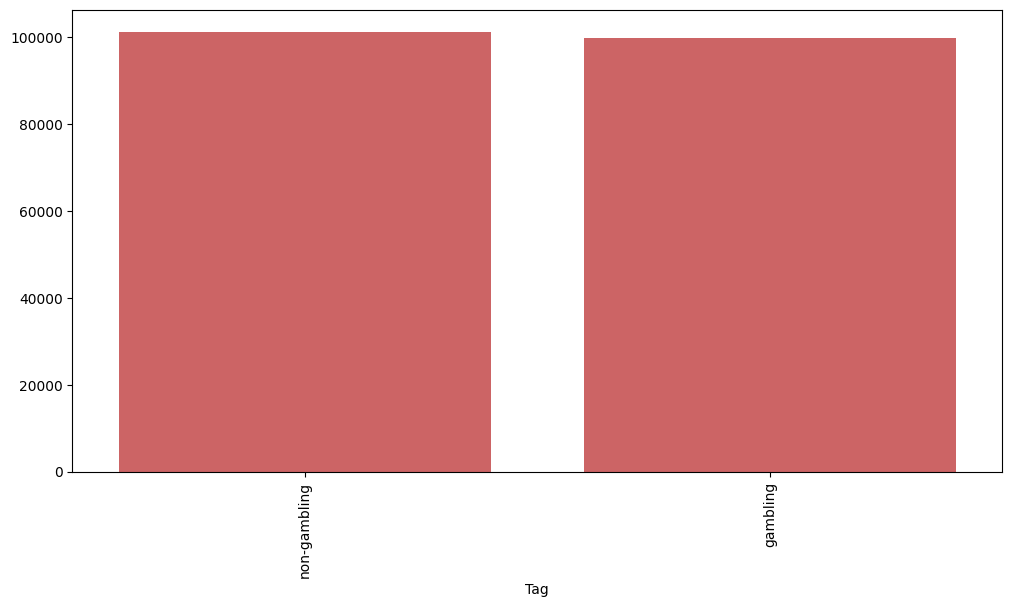

In [9]:
cnt_tag = df['Tag'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=cnt_tag.index, y=cnt_tag.values, alpha=0.8, color=color[3])
plt.xticks(rotation='vertical')
plt.show()

In [10]:
all_words = ' '.join([text for text in df['Url']])
wordcloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110).generate(all_words)

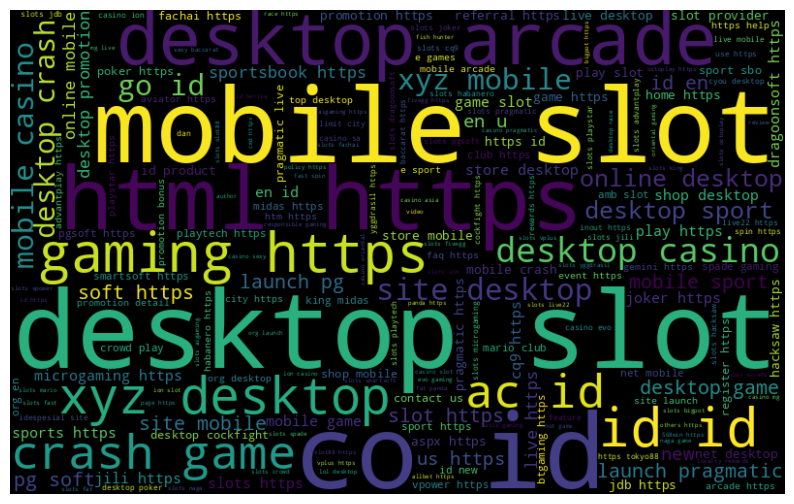

In [11]:
plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

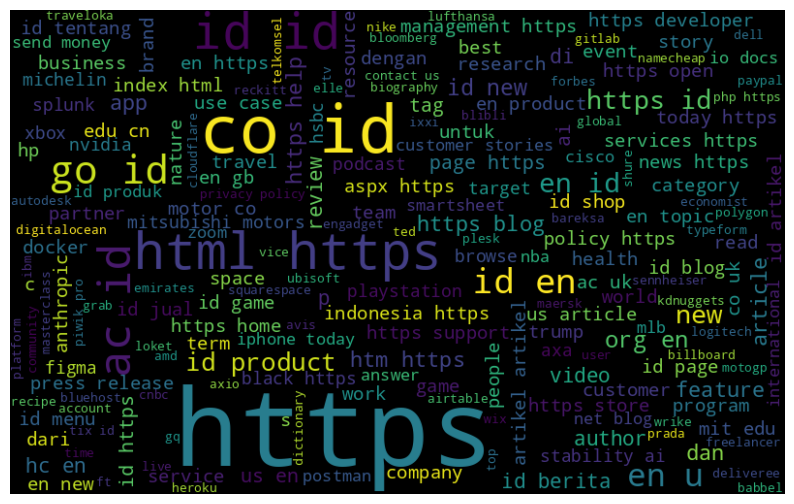

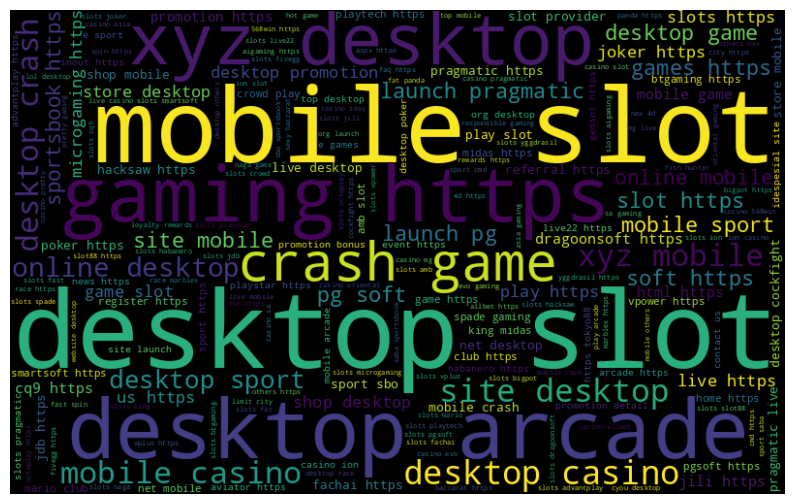

In [12]:
for tag in ("non-gambling", "gambling"):
    words = " ".join(t for t in df[df["Tag"] == tag]["Url"])
    wc = WordCloud(width=800, height=500, random_state=21, max_font_size=110).generate(
        words
    )
    plt.figure(figsize=(10, 7))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()

# Data Preprocessing & Cleaning

In [13]:
def clean_url(url_string):
    url = unquote(url_string).lower()
    url = re.sub(r"https?:\/\/", "", url)
    url = re.sub(r"[-_/]", " ", url)
    url = re.sub(r"[^a-zA-Z0-9\s]", " ", url)
    url = re.sub(r"(\d)([a-z])", r"\1 \2", url)
    url = re.sub(r"([a-z])(\d)", r"\1 \2", url)
    url = re.sub(r"\s+", " ", url).strip()
    return url

In [14]:
df['cleaned_url'] = df['Url'].apply(clean_url)
df['cleaned_url'].head()

0             abcnews go com live
1    abcnews go com international
2        abcnews go com lifestyle
3               abcnews go com us
4         abcnews go com business
Name: cleaned_url, dtype: str

In [15]:
TAG_DICT = {"non-gambling":0, "gambling": 1}
df['target'] = df.Tag.map(TAG_DICT)
display(df["target"].head(), df["target"].tail())

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

201173    1
201174    1
201175    1
201176    1
201177    1
Name: target, dtype: int64

In [16]:
# (URL dari domain yg sama tidak boleh terpisah train/val)
df["domain_group"] = df["Domain"].values
df["domain_group"].head()
df["domain_group"].tail()

201173    zipzapslotvip.best
201174    zipzapslotvip.best
201175    zipzapslotvip.best
201176    zipzapslotvip.best
201177    zipzapslotvip.best
Name: domain_group, dtype: str

In [17]:
X_text = df["cleaned_url"].to_numpy()
y = df["target"].values
groups = df["domain_group"].values

gkf = GroupKFold(n_splits=5)
cvlist = list(gkf.split(df, y, groups=groups))

# Feature Engineering

#### Bag of Words

In [18]:
bow_pipe = Pipeline(
    [
        ("vec", CountVectorizer(ngram_range=(1, 3), min_df=400)),
        ("clf", MultinomialNB(alpha=1.0)),
    ]
)

In [19]:
bow_scores = cross_val_score(bow_pipe, X_text, y, cv=cvlist, scoring="f1")

#### Character N-Grams

In [20]:
char_ngram_pipe = Pipeline([
    (
        "union",
        FeatureUnion([
            (
                "char",
                CountVectorizer(
                    analyzer="char",
                    ngram_range=(1, 5),
                    min_df=500
                ),
            ),
            (
                "word",
                CountVectorizer(
                    analyzer="word",
                    ngram_range=(1, 3),
                    min_df=400
                ),
            ),
        ]),
    ),
    (
        "clf",
        MultinomialNB(alpha=1.0),
    ),
])

In [21]:
char_ngram_scores = cross_val_score(
    char_ngram_pipe, X_text, y, cv=cvlist, scoring="f1"
)

#### TFIDF Features

In [22]:
tfidf_pipe = Pipeline([
    (
        "union",
        FeatureUnion([
            (
                "char",
                TfidfVectorizer(
                    analyzer="char",
                    ngram_range=(1, 5),
                    min_df=500
                ),
            ),
            (
                "word",
                TfidfVectorizer(
                    analyzer="word",
                    ngram_range=(1, 3),
                    min_df=400
                ),
            ),
        ]),
    ),
    (
        "clf",
        MultinomialNB(alpha=1.0),
    ),
])

In [23]:
tfidf_scores = cross_val_score(
    tfidf_pipe, X_text, y, cv=cvlist, scoring="f1"
)

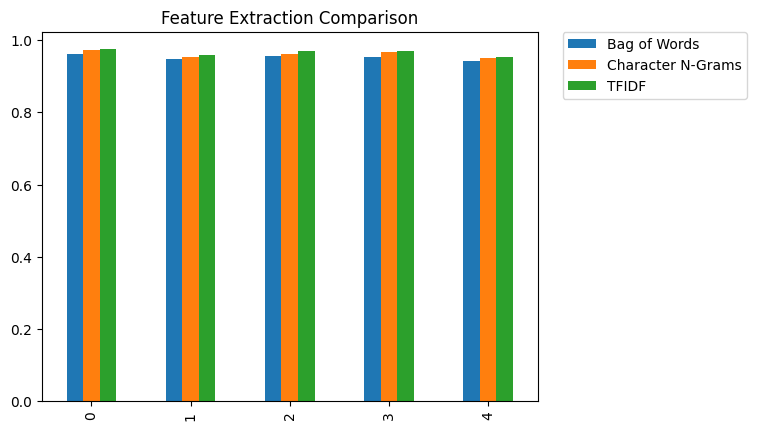

In [24]:
feat_results = pd.DataFrame(
    {
        "Bag of Words": bow_scores,
        "Character N-Grams": char_ngram_scores,
        "TFIDF": tfidf_scores,
    }
)

feat_results.plot(kind="bar")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)
plt.title("Feature Extraction Comparison")
plt.show()

In [25]:
feat_summary = pd.DataFrame({
        "Mean F1-Score": feat_results.mean(),
        "Std Deviasi (Kestabilan)": feat_results.std(),
    }).sort_values(
        by=["Mean F1-Score", "Std Deviasi (Kestabilan)"],
        ascending=[False, True],
    )

print("=== Peringkat Feature Extraction ===")
print(feat_summary)
print("-" * 30)
best_feat_name = feat_summary.index[0]
best_feat_score = feat_summary["Mean F1-Score"].iloc[0]
print(f"\nFeature terbaik: {best_feat_name} (F1 = {best_feat_score:.4f})")

=== Peringkat Feature Extraction ===
                   Mean F1-Score  Std Deviasi (Kestabilan)
TFIDF                   0.964893                  0.008811
Character N-Grams       0.960844                  0.009673
Bag of Words            0.951660                  0.007515
------------------------------

Feature terbaik: TFIDF (F1 = 0.9649)


In [26]:
_tfidf_union = FeatureUnion(
    [
        ("char", TfidfVectorizer(analyzer="char", ngram_range=(1, 5), min_df=500)),
        ("word", TfidfVectorizer(analyzer="word", ngram_range=(1, 3), min_df=400)),
    ]
)

# Model Evaluation & Cross Validation

#### Naive Bayes

In [27]:
nb_pipe = Pipeline([("feat", _tfidf_union), ("clf", MultinomialNB(alpha=1.0))])
nb_scores = cross_val_score(nb_pipe, X_text, y, cv=cvlist, scoring="f1")

#### Logistic Regression

In [28]:
lr_pipe = Pipeline(
    [("feat", _tfidf_union), ("clf", LogisticRegression(C=0.1, max_iter=1000))]
)
lr_scores = cross_val_score(lr_pipe, X_text, y, cv=cvlist, scoring="f1")

#### Tree Based Methods

In [29]:
dt_pipe = Pipeline(
    [
        ("feat", _tfidf_union),
        ("clf", DecisionTreeClassifier(min_samples_leaf=25, min_samples_split=25)),
    ]
)
dt_scores = cross_val_score(dt_pipe, X_text, y, cv=cvlist, scoring="f1")

#### Random Forest

In [30]:
rf_pipe = Pipeline(
    [
        ("feat", _tfidf_union),
        (
            "clf",
            RandomForestClassifier(
                random_state=0, n_estimators=100, max_depth=50
            ),
        ),
    ]
)
rf_scores = cross_val_score(rf_pipe, X_text, y, cv=cvlist, scoring="f1")

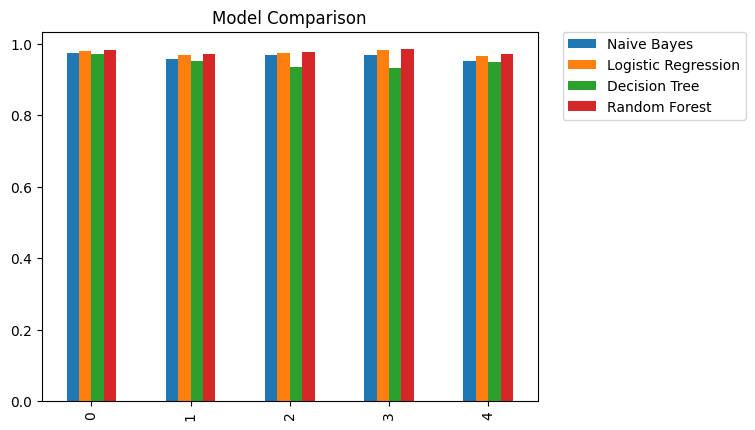

In [31]:
model_results = pd.DataFrame(
    {
        "Naive Bayes": nb_scores,
        "Logistic Regression": lr_scores,
        "Decision Tree": dt_scores,
        "Random Forest": rf_scores,
    }
)
model_results.plot(kind="bar")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)
plt.title("Model Comparison")
plt.show()

#### Deep Learning

In [32]:
def create_dl_model(input_dim):
    model = Sequential()
    
    model.add(Dense(64, 
                    kernel_regularizer=l2(1e-4), 
                    input_dim=input_dim))
    model.add(LeakyReLU(negative_slope=0.01))
    model.add(Dropout(0.40))
    
    model.add(Dense(32, 
                    kernel_regularizer=l2(1e-4)))
    model.add(LeakyReLU(negative_slope=0.01))
    model.add(Dropout(0.40))
    
    model.add(Dense(1, activation='sigmoid'))
    
    return model

In [33]:
def cv_dl(X_text, y, cvlist, epochs=35, batch_size=128):
    fold_scores = []

    for fold, (train_idx, val_idx) in enumerate(cvlist, 1):
        print(f"\n===== Fold {fold}/{len(cvlist)} =====")
        X_tr, X_val = X_text[train_idx], X_text[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        
        fold_tfidf_union = FeatureUnion([
            ("char", TfidfVectorizer(analyzer="char", ngram_range=(1, 5), min_df=500)),
            ("word", TfidfVectorizer(analyzer="word", ngram_range=(1, 3), min_df=400)),
        ])

        X_tr_tfidf = fold_tfidf_union.fit_transform(X_tr)
        X_val_tfidf = fold_tfidf_union.transform(X_val)
        
        input_dim = X_tr_tfidf.shape[1]
        
        model = create_dl_model(input_dim)
        
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), 
            loss="binary_crossentropy",
            metrics=['accuracy', 'precision', 'recall']
        )

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=6, restore_best_weights=True,
        )
        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5,
        )
        
        model.fit(
            X_tr_tfidf, y_tr,
            validation_data=(X_val_tfidf, y_val),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=[early_stop, reduce_lr],
            verbose=1,
        )

        y_pred_prob = model.predict(X_val_tfidf, verbose=0).ravel()

        thresholds = np.arange(0.3, 0.71, 0.02)
        best_f1, best_thresh = 0, 0.5
        for t in thresholds:
            y_pred = (y_pred_prob > t).astype(int)
            f1 = f1_score(y_val, y_pred)
            if f1 > best_f1:
                best_f1, best_thresh = f1, t

        fold_scores.append(best_f1)
        print(f"Fold {fold} F1-Score Resmi: {best_f1:.4f} (th={best_thresh:.2f})")

    return fold_scores

In [34]:
dl_scores = cv_dl(X_text, y, cvlist)


===== Fold 1/5 =====


E0000 00:00:1781612924.178563    1656 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/35
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.9877 - loss: 0.0844 - precision: 0.9887 - recall: 0.9859 - val_accuracy: 0.9834 - val_loss: 0.0724 - val_precision: 0.9872 - val_recall: 0.9822 - learning_rate: 5.0000e-04
Epoch 2/35
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9974 - loss: 0.0298 - precision: 0.9978 - recall: 0.9969 - val_accuracy: 0.9806 - val_loss: 0.0803 - val_precision: 0.9835 - val_recall: 0.9809 - learning_rate: 5.0000e-04
Epoch 3/35
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 13s 11ms/step - accuracy: 0.9981 - loss: 0.0244 - precision: 0.9984 - recall: 0.9978 - val_accuracy: 0.9824 - val_loss: 0.0759 - val_precision: 0.9897 - val_recall: 0.9778 - learning_rate: 5.0000e-04
Epoch 4/35
1258/1258 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.9981 - loss: 0.0223 - precision: 0.9983 - recall: 0.9978 - val_accuracy: 0.9807 - val_loss: 0.0779 - val_precision: 0.9842 - val_recall: 0.9802 - learning_rate: 5.0000e-04
Epoch 5/35
1258/1258 ━━━━━━━━━━━━━

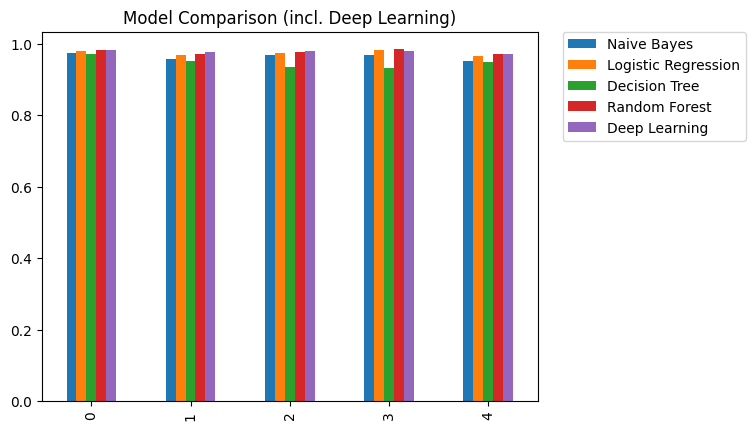

In [35]:
model_results["Deep Learning"] = dl_scores
model_results.plot(kind="bar")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.0)
plt.title("Model Comparison (incl. Deep Learning)")
plt.show()

In [36]:
full_summary = pd.DataFrame(
    {
        "Mean F1-Score": model_results.mean(),
        "Std Deviasi (Kestabilan)": model_results.std(),
    }
).sort_values(
    by=["Mean F1-Score", "Std Deviasi (Kestabilan)"],
    ascending=[False, True],
)
print("=== Peringkat Model ===")
print(full_summary)
print("-" * 30)
best_model_name = full_summary.index[0]
best_model_f1 = full_summary["Mean F1-Score"].iloc[0]
print(f"\nModel terbaik: {best_model_name} (F1 = {best_model_f1:.4f})")

=== Peringkat Model ===
                     Mean F1-Score  Std Deviasi (Kestabilan)
Deep Learning             0.978809                  0.005060
Random Forest             0.977652                  0.006336
Logistic Regression       0.974574                  0.006909
Naive Bayes               0.964893                  0.008811
Decision Tree             0.948056                  0.016103
------------------------------

Model terbaik: Deep Learning (F1 = 0.9788)


In [37]:
oof_probs = np.zeros(len(y))

for fold, (train_idx, val_idx) in enumerate(cvlist, 1):

    print(f"Fold {fold}")

    X_tr = X_text[train_idx]
    X_val = X_text[val_idx]

    y_tr = y[train_idx]

    fold_tfidf = FeatureUnion([
        (
            "char",
            TfidfVectorizer(
                analyzer="char",
                ngram_range=(1, 5),
                min_df=500,
            ),
        ),
        (
            "word",
            TfidfVectorizer(
                analyzer="word",
                ngram_range=(1, 3),
                min_df=400,
            ),
        ),
    ])

    X_tr_tfidf = fold_tfidf.fit_transform(X_tr)
    X_val_tfidf = fold_tfidf.transform(X_val)

    model = create_dl_model(X_tr_tfidf.shape[1])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=0.0005
        ),
        loss="binary_crossentropy",
    )

    model.fit(
        X_tr_tfidf,
        y_tr,
        epochs=20,
        batch_size=128,
        verbose=0,
    )

    oof_probs[val_idx] = (
        model.predict(X_val_tfidf, verbose=0)
        .ravel()
    )

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5


In [38]:
thresholds = np.arange(0.30, 0.71, 0.02)

best_thresh = 0.5
best_f1 = 0

for th in thresholds:

    pred = (oof_probs > th).astype(int)

    score = f1_score(y, pred)

    if score > best_f1:
        best_f1 = score
        best_thresh = th

print(f"Best Threshold : {best_thresh:.2f}")
print(f"Best F1        : {best_f1:.4f}")

Best Threshold : 0.70
Best F1        : 0.9754


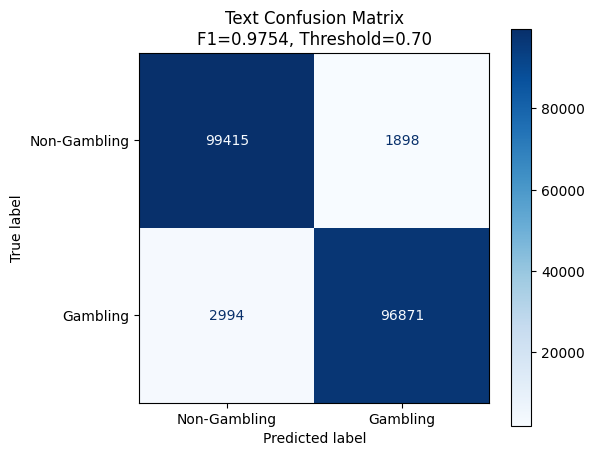

              precision    recall  f1-score   support

Non-Gambling     0.9708    0.9813    0.9760    101313
    Gambling     0.9808    0.9700    0.9754     99865

    accuracy                         0.9757    201178
   macro avg     0.9758    0.9756    0.9757    201178
weighted avg     0.9757    0.9757    0.9757    201178



In [39]:
oof_pred = (oof_probs > best_thresh).astype(int)

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y,
    oof_pred,
    display_labels=[
        "Non-Gambling",
        "Gambling",
    ],
    cmap="Blues",
    values_format="d",
    ax=ax,
)

ax.set_title(
    f"Text Confusion Matrix\n"
    f"F1={best_f1:.4f}, Threshold={best_thresh:.2f}"
)

plt.tight_layout()
plt.show()

print(
    classification_report(
        y,
        oof_pred,
        target_names=[
            "Non-Gambling",
            "Gambling",
        ],
        digits=4,
    )
)

In [40]:
SAVE_DIR = "./bin"
os.makedirs(SAVE_DIR, exist_ok=True)

X_train_full = X_text
y_train_full = y

final_tfidf = FeatureUnion([
    (
        "char",
        TfidfVectorizer(
            analyzer="char",
            ngram_range=(1, 5),
            min_df=500,
        ),
    ),
    (
        "word",
        TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 3),
            min_df=400,
        ),
    ),
])

X_train_tfidf = final_tfidf.fit_transform(X_train_full)

input_dim = X_train_tfidf.shape[1]

final_model = create_dl_model(input_dim)

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0005
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        "precision",
        "recall",
    ],
)

final_model.fit(
    X_train_tfidf,
    y_train_full,
    epochs=20,
    batch_size=128,
    verbose=1,
)

print(f"\nUsing Threshold: {best_thresh:.2f}")

Epoch 1/20
1572/1572 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9883 - loss: 0.0757 - precision: 0.9888 - recall: 0.9877
Epoch 2/20
1572/1572 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9974 - loss: 0.0291 - precision: 0.9980 - recall: 0.9967
Epoch 3/20
1572/1572 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9979 - loss: 0.0251 - precision: 0.9983 - recall: 0.9974
Epoch 4/20
1572/1572 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9981 - loss: 0.0225 - precision: 0.9983 - recall: 0.9978
Epoch 5/20
1572/1572 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9982 - loss: 0.0211 - precision: 0.9985 - recall: 0.9979
Epoch 6/20
1572/1572 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9981 - loss: 0.0200 - precision: 0.9983 - recall: 0.9979
Epoch 7/20
1572/1572 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9984 - loss: 0.0187 - precision: 0.9986 - recall: 0.9982
Epoch 8/20
1572/1572 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9983 - loss: 0.0183 - precision: 0.9986 -

In [41]:
final_model.save(f"{SAVE_DIR}/text_classifier.keras")

with open(f"{SAVE_DIR}/text_tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(final_tfidf, f)

with open(f"{SAVE_DIR}/text_best_threshold.pkl", "wb") as f:
    pickle.dump(best_thresh, f)

with open(f"{SAVE_DIR}/text_best_threshold.json", "w") as f:
    json.dump(
        {
            "text_best_threshold": float(best_thresh),
            "f1_score": float(best_f1),
        },
        f,
        indent=2,
    )

print("\nSaved:")
print(f"{SAVE_DIR}/text_classifier.keras")
print(f"{SAVE_DIR}/text_tfidf_vectorizer.pkl")
print(f"{SAVE_DIR}/text_best_threshold.pkl")
print(f"{SAVE_DIR}/text_best_threshold.json")


Saved:
./bin/text_classifier.keras
./bin/text_tfidf_vectorizer.pkl
./bin/text_best_threshold.pkl
./bin/text_best_threshold.json


In [42]:
loaded_model = tf.keras.models.load_model(f"{SAVE_DIR}/text_classifier.keras")

with open(f"{SAVE_DIR}/text_tfidf_vectorizer.pkl", "rb") as f:
    loaded_tfidf = pickle.load(f)

with open(f"{SAVE_DIR}/text_best_threshold.pkl", "rb") as f:
    loaded_thresh = pickle.load(f)

In [43]:
test_urls = [
    "https://id.hotels.com/helpcenter",
    "https://askubuntu.com/questions/698700/how-to-configure-git-user-name-and-email",
    "https://jagoledak8kgs.live/",
    "https://naga15jp1.live/home?register&ref=ngbos5396",
    "https://id.wiktionary.org/wiki/gambling",
    "https://jabar.nu.or.id/syariah/mengenal-3-ayat-al-qur-an-tentang-judi-dan-tafsirnya-eII1L",
]

print("\n" + "-" * 100)
print(f"Threshold = {loaded_thresh:.2f}")
print("-" * 100)

for url in test_urls:

    cleaned = clean_url(url)

    features = loaded_tfidf.transform(
        [cleaned]
    )

    features.sort_indices()

    prob = (
        loaded_model.predict(
            features,
            verbose=0,
        )[0][0]
    )

    pred = int(prob > loaded_thresh)

    label = (
        "gambling"
        if pred == 1
        else "non-gambling"
    )

    print(
        f"{label:14s} "
        f"(prob={prob:.4f}) "
        f"{url}"
    )


----------------------------------------------------------------------------------------------------
Threshold = 0.70
----------------------------------------------------------------------------------------------------
non-gambling   (prob=0.0051) https://id.hotels.com/helpcenter
non-gambling   (prob=0.0001) https://askubuntu.com/questions/698700/how-to-configure-git-user-name-and-email
gambling       (prob=1.0000) https://jagoledak8kgs.live/
gambling       (prob=0.9998) https://naga15jp1.live/home?register&ref=ngbos5396
non-gambling   (prob=0.0001) https://id.wiktionary.org/wiki/gambling
non-gambling   (prob=0.0014) https://jabar.nu.or.id/syariah/mengenal-3-ayat-al-qur-an-tentang-judi-dan-tafsirnya-eII1L
